# Rural Theater Reviews Analytics

The purpose of this project is to use natural language processing (NLP), sentiment analysis, topic modeling, and theme comparison to answer the question:


### What factors most influence customer satisfaction at rural performing arts venues?

<br>

#### Additional thinking questions:
- Are visitors discussing the performance itself or the broader tourism experience?
- What operational issues most affect customer ratings?
- Do tourists value different aspects of the experience than local patrons? <br>

<br>

#### Tools:
- Overall:
    - Python, pandas, numpy, matplotlib, seaborn
- Sentiment Analysis:
    - NLTK, Hugging Face, Scikit <br>
- Topic modeling
    - BERTopic

<br>

#### Data:
The dataset consists of 650+ publicly available reviews from five theaters in a rural, tourism-based locality. Web scraped using Google Sheets, Apify, and Make.com. While the findings may not generalize to large urban performing centers, they provide insight into customer experiences and satisfaction drivers within comparable rural arts organizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df = pd.read_csv("Reviews Scraping - Data.csv")

df.head()

,Reviewer Name,Review Text,Published Date,Stars Given,Review URL,Owner Response Text,Venue name
0,Troy Everett,NaN,2026-02-02T17:58:49.434Z,5,https://www.google.com/maps/contrib/1007492457...,NaN,Door Shakespeare Day Time Office and Gift Shop
1,Zarata Tapsoba,Friendly staff❤️Great show !!❤️,2025-08-13T21:44:29.416Z,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop
2,Luther Snow,Best theater in Door County. Among the best S...,2025-08-08T21:54:25.906Z,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop
3,nancy mcgrath,Absolutely wonderful production! Our family me...,2025-07-29T04:33:19.793Z,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop
4,Jade D,My favorite part of Door County!!!! Absolutely...,2025-07-05T23:51:56.945Z,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop


### Preproduction EDA

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 655 entries, 0 to 654
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Reviewer Name        655 non-null    str  
 1   Review Text          446 non-null    str  
 2   Published Date       655 non-null    str  
 3   Stars Given          655 non-null    int64
 4   Review URL           655 non-null    str  
 5   Owner Response Text  394 non-null    str  
 6   Venue name           655 non-null    str  
dtypes: int64(1), str(6)
memory usage: 35.9 KB


In [3]:
df.isnull().sum()

Reviewer Name            0
Review Text            209
Published Date           0
Stars Given              0
Review URL               0
Owner Response Text    261
Venue name               0
dtype: int64

Text(0.5, 0, 'Review Stars')

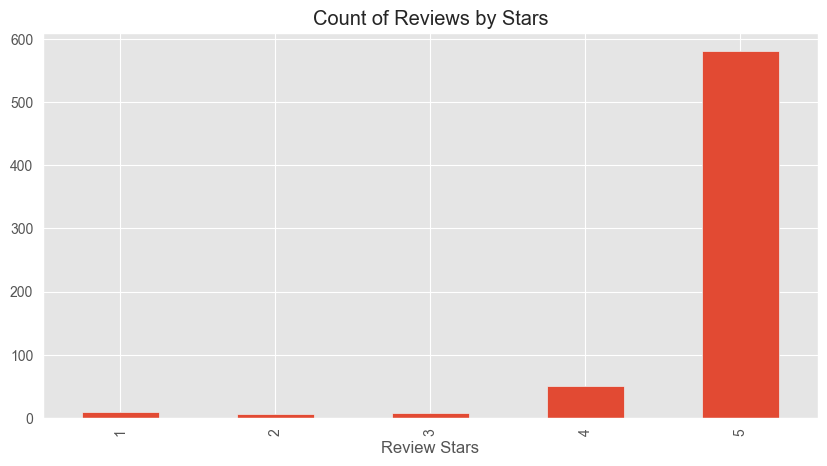

In [4]:
ax = (df['Stars Given'].value_counts().sort_index()
      .plot(kind='bar',
            title='Count of Reviews by Stars',
            figsize=(10,5)))
ax.set_xlabel('Review Stars')

In [5]:
percentages = df['Stars Given'].value_counts(normalize=True).sort_index() * 100
percentages

Stars Given
1     1.526718
2     0.916031
3     1.221374
4     7.786260
5    88.549618
Name: proportion, dtype: float64

Nearly 90% of the reviews are five stars, and over 95% are "positive" (4 or 5 stars). This shows a strong positive skew in the dataset, which has important implications for model evaluation. The extreme class imbalance means high overall accuracy is easily achieved, and performance in the minority negative and neutral classes will be a more meaningful indicator of model quality.

In [6]:
df['word_count'] = df['Review Text'].str.split().str.len()
df['word_count'].describe()

count    446.000000
mean      25.764574
std       32.217947
min        1.000000
25%        7.000000
50%       14.000000
75%       32.750000
max      308.000000
Name: word_count, dtype: float64

### Data Cleaning

In [7]:
# feature name normalization
df = df.rename(columns={
    "Reviewer Name": "reviewer_name",
    "Review Text": "review_text",
    "Published Date": "published_date",
    "Stars Given": "stars_given",
    "Review URL": "review_url",
    "Owner Response Text": "owner_response_text",
    "Venue name": "venue_name"
})

# use only reviews with text
df = df.dropna(subset=['review_text'])
df = df.drop_duplicates()
df = df[df['review_text'].str.strip() != ""]

# remove very short reviews
df = df[df['word_count'] >= 3]

df.shape

(420, 8)

In [8]:
import re
# create light cleaned text (for sentiment analysis) and full cleaned text (for topic modeling)
def light_clean_text(txt):
    """
    function that lightly cleans up text
    :param txt: uncleaned text
    :return: lightly cleaned text
    """
    txt = str(txt)
    txt = re.sub(r"http\S+", "", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

def full_clean_text(txt):
    """
    function that fully cleans up text
    :param txt: uncleaned text
    :return: fully cleaned text
    """
    txt = str(txt).lower()
    txt = re.sub(r"http\S+", "", txt)
    txt = re.sub(r"[^a-zA-Z\s]", "", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

df['light_clean_review'] = df['review_text'].apply(light_clean_text)
df['full_clean_review'] = df['review_text'].apply(full_clean_text)

# type conversion to datetime
df['published_date'] = pd.to_datetime(df['published_date']).dt.date

df = df.drop(columns=["reviewer_name"])

df.head()

,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review
1,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show
2,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...
3,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...
4,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...
6,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...


### NLTK: VADERS Baseline Sentiment Analysis

In [9]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [10]:
res = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['light_clean_review']
    res[i] = sia.polarity_scores(text)


vaders = pd.DataFrame(res).T
vaders = vaders.merge(df, left_index=True, right_index=True, how='left')
vaders = vaders.rename(columns={'neg' : 'vaders_neg', 'neu' : 'vaders_neu', 'pos' : 'vaders_pos', 'compound' : 'vaders_compound'})
vaders.head()

  0%|          | 0/420 [00:00<?, ?it/s]

,vaders_neg,vaders_neu,vaders_pos,vaders_compound,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review
1,0.000,0.442,0.558,0.5837,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show
2,0.000,0.616,0.384,0.9862,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...
3,0.000,0.698,0.302,0.9540,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...
4,0.000,0.685,0.315,0.8504,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...
6,0.119,0.692,0.189,0.2144,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...


### HuggingFace's Roberta Model (Pretrained Transformer model)

In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

example = df.iloc[150]['light_clean_review']
print(sia.polarity_scores(example))
print(example)

{'neg': 0.0, 'neu': 0.496, 'pos': 0.504, 'compound': 0.9458}
Wow. What a special place with special people and a special performance! A visit to Door County will never be complete without a show. Wow!


In [14]:
roberta_MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
roberta_tokenizer = AutoTokenizer.from_pretrained(roberta_MODEL)
roberta_model = AutoModelForSequenceClassification.from_pretrained(roberta_MODEL)

encoded_text = roberta_tokenizer(example, return_tensors='pt')
output = roberta_model(**encoded_text)
scores = output.logits[0].detach().numpy()
scores = softmax(scores)

scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}

scores_dict = {
    k: round(float(v), 3)
    for k, v in scores_dict.items()
}

print(scores_dict)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'roberta_neg': 0.002, 'roberta_neu': 0.011, 'roberta_pos': 0.988}


In [15]:
def polarity_scores_roberta(txt):
    """
    function that scores input text on sentiment analysis based on pretrained roberta model
    :param txt: input text
    :return: a dictionary of negative, neutral, and positive scores
    """
    encoded_txt = roberta_tokenizer(txt, return_tensors='pt')
    txt_output = roberta_model(**encoded_txt)
    txt_scores = txt_output.logits[0].detach().numpy()
    txt_scores = softmax(txt_scores)
    txt_scores_dict = {
        'roberta_neg' : txt_scores[0],
        'roberta_neu' : txt_scores[1],
        'roberta_pos' : txt_scores[2]
    }
    return txt_scores_dict


res2 = {}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['light_clean_review']
    res2[i] = polarity_scores_roberta(text)


roberta = pd.DataFrame(res2).T
roberta = roberta.merge(df, left_index=True, right_index=True, how='left')
roberta['roberta_compound'] = roberta['roberta_pos'] - roberta['roberta_neg']
roberta.head()

  0%|          | 0/420 [00:00<?, ?it/s]

,roberta_neg,roberta_neu,roberta_pos,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review,roberta_compound
1,0.001475,0.008463,0.990062,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show,0.988587
2,0.001849,0.013335,0.984815,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...,0.982966
3,0.001277,0.007027,0.991696,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...,0.990419
4,0.002348,0.006077,0.991575,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...,0.989227
6,0.400849,0.337175,0.261975,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...,-0.138874


In [ ]:
sentiment_df = df.copy()

sentiment_df = sentiment_df.merge(
    vaders[["vaders_neg", "vaders_neu", "vaders_pos", "vaders_compound"]],
    left_index=True,
    right_index=True,
    how="left"
)

sentiment_df = sentiment_df.merge(
    roberta[["roberta_neg", "roberta_neu", "roberta_pos", "roberta_compound"]],
    left_index=True,
    right_index=True,
    how="left"
)

sentiment_df.head()

### Sentiment Analysis Evaluation

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def label_from_stars(stars):
    """
    function that labels sentiment as positive, neutral, or negative, based on the number of stars given in a rating
    :param stars: star rating
    :return: sentiment label
    """
    if stars >= 4:
        return 'positive'
    elif stars == 3:
        return 'neutral'
    else:
        return 'negative'

sentiment_df['true_label'] = sentiment_df['stars_given'].apply(label_from_stars)

def label_from_compound(score):
    if score >= 0.1:
        return 'positive'
    if score <= -0.1:
        return 'negative'
    else:
        return 'neutral'

sentiment_df['vaders_label'] = sentiment_df['vaders_compound'].apply(label_from_compound)
sentiment_df['roberta_label'] = sentiment_df['roberta_compound'].apply(label_from_compound)

sentiment_df.head()

,review_text,published_date,stars_given,review_url,owner_response_text,venue_name,word_count,light_clean_review,full_clean_review,vaders_neg,...,vaders_compound,roberta_neg,roberta_neu,roberta_pos,roberta_compound,vaders_predicted_stars,roberta_predicted_stars,true_label,vaders_label,roberta_label
1,Friendly staff❤️Great show !!❤️,2025-08-13,5,https://www.google.com/maps/contrib/1080433602...,NaN,Door Shakespeare Day Time Office and Gift Shop,4.0,Friendly staff❤️Great show !!❤️,friendly staffgreat show,0.000,...,0.5837,0.001475,0.008463,0.990062,0.988587,4.1674,5.0,positive,positive,positive
2,Best theater in Door County. Among the best S...,2025-08-08,5,https://www.google.com/maps/contrib/1150446054...,Hello Luther!\n\nThank you so much for your ki...,Door Shakespeare Day Time Office and Gift Shop,64.0,Best theater in Door County. Among the best Sh...,best theater in door county among the best sha...,0.000,...,0.9862,0.001849,0.013335,0.984815,0.982966,4.9724,5.0,positive,positive,positive
3,Absolutely wonderful production! Our family me...,2025-07-29,5,https://www.google.com/maps/contrib/1037561463...,"Hello, Nancy!\n\nDelighted to hear that you an...",Door Shakespeare Day Time Office and Gift Shop,45.0,Absolutely wonderful production! Our family me...,absolutely wonderful production our family mem...,0.000,...,0.9540,0.001277,0.007027,0.991696,0.990419,4.9080,5.0,positive,positive,positive
4,My favorite part of Door County!!!! Absolutely...,2025-07-05,5,https://www.google.com/maps/contrib/1102217076...,"Thank you so much, Jade! We're thrilled to hea...",Door Shakespeare Day Time Office and Gift Shop,21.0,My favorite part of Door County!!!! Absolutely...,my favorite part of door county absolutely ama...,0.000,...,0.8504,0.002348,0.006077,0.991575,0.989227,4.7008,5.0,positive,positive,positive
6,"Recently, attended the Shakespeare play “As yo...",2023-08-16,3,https://www.google.com/maps/contrib/1024878977...,NaN,Door Shakespeare Day Time Office and Gift Shop,47.0,"Recently, attended the Shakespeare play “As yo...",recently attended the shakespeare play as you ...,0.119,...,0.2144,0.400849,0.337175,0.261975,-0.138874,3.4288,3.0,neutral,positive,negative


In [28]:
labels = ['negative', 'neutral', 'positive']

print("VADERS classification report")
print(classification_report(
    sentiment_df['true_label'],
    sentiment_df['vaders_label'],
    labels=labels,
    zero_division=0
))
print("\n")
print("RoBERTa classification report")
print(classification_report(
    sentiment_df['true_label'],
    sentiment_df['roberta_label'],
    labels=labels,
    zero_division=0
))

print("VADER predicted distribution:")
print(sentiment_df['vaders_label'].value_counts())

print("\nRoBERTa predicted distribution:")
print(sentiment_df['roberta_label'].value_counts())

print("\nTrue label distribution:")
print(sentiment_df['true_label'].value_counts())

VADERS classification report
              precision    recall  f1-score   support

    negative       0.69      0.56      0.62        16
     neutral       0.00      0.00      0.00         5
    positive       0.98      0.97      0.97       399

    accuracy                           0.94       420
   macro avg       0.56      0.51      0.53       420
weighted avg       0.95      0.94      0.95       420



RoBERTa classification report
              precision    recall  f1-score   support

    negative       0.59      0.81      0.68        16
     neutral       0.00      0.00      0.00         5
    positive       0.99      0.98      0.98       399

    accuracy                           0.96       420
   macro avg       0.53      0.60      0.56       420
weighted avg       0.96      0.96      0.96       420

VADER predicted distribution:
vaders_label
positive    396
negative     13
neutral      11
Name: count, dtype: int64

RoBERTa predicted distribution:
roberta_label
positive    3

VADER Binary Report
              precision    recall  f1-score   support

    negative       0.75      0.56      0.64        16
    positive       0.99      0.97      0.98       399

   micro avg       0.98      0.95      0.97       415
   macro avg       0.87      0.77      0.81       415
weighted avg       0.98      0.95      0.97       415

RoBERTa Binary Report
              precision    recall  f1-score   support

    negative       0.65      0.81      0.72        16
    positive       0.99      0.98      0.99       399

   micro avg       0.98      0.98      0.98       415
   macro avg       0.82      0.90      0.86       415
weighted avg       0.98      0.98      0.98       415



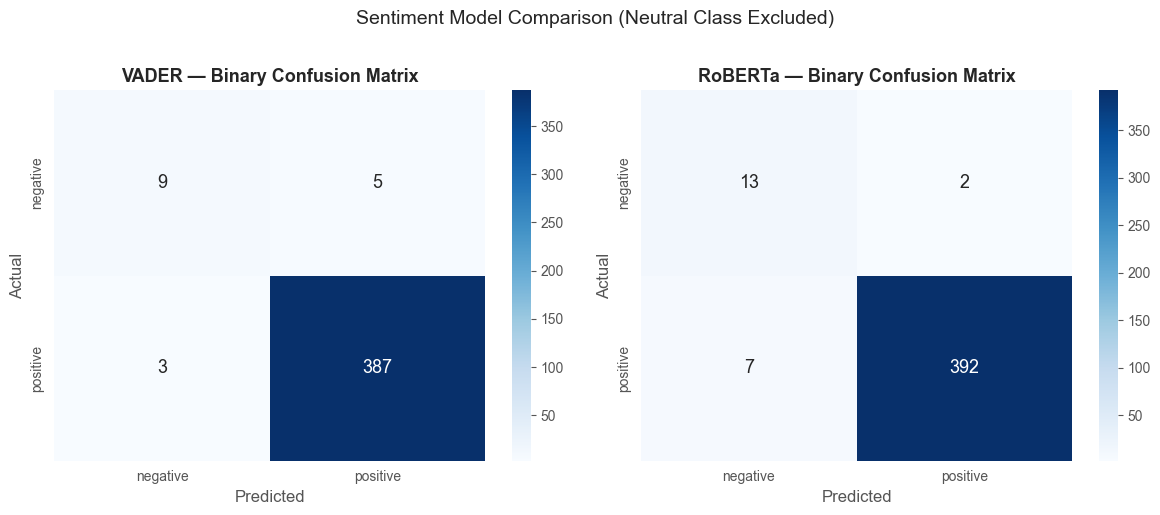

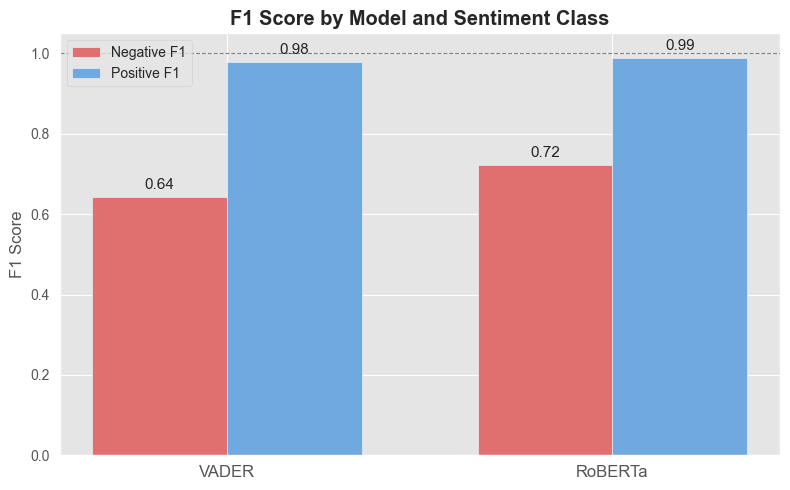

In [30]:
# ── Drop neutral, binary evaluation ──────────────────────────────────────────
binary_df = sentiment_df[sentiment_df['true_label'] != 'neutral'].copy()

print("VADER Binary Report")
print(classification_report(
    binary_df['true_label'],
    binary_df['vaders_label'],
    labels=['negative', 'positive'],
    zero_division=0
))

print("RoBERTa Binary Report")
print(classification_report(
    binary_df['true_label'],
    binary_df['roberta_label'],
    labels=['negative', 'positive'],
    zero_division=0
))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
binary_labels = ['negative', 'positive']

for ax, pred_col, title in zip(
    axes,
    ['vaders_label', 'roberta_label'],
    ['VADER', 'RoBERTa']
):
    cm = confusion_matrix(
        binary_df['true_label'],
        binary_df[pred_col],
        labels=binary_labels
    )
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=binary_labels,
        yticklabels=binary_labels,
        ax=ax,
        annot_kws={"size": 13}
    )
    ax.set_title(f'{title} — Binary Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Sentiment Model Comparison (Neutral Class Excluded)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


models = ['VADER', 'RoBERTa']

f1_negative = [
    f1_score(binary_df['true_label'], binary_df['vaders_label'],  labels=['negative', 'positive'], average=None, zero_division=0)[0],
    f1_score(binary_df['true_label'], binary_df['roberta_label'], labels=['negative', 'positive'], average=None, zero_division=0)[0],
]
f1_positive = [
    f1_score(binary_df['true_label'], binary_df['vaders_label'],  labels=['negative', 'positive'], average=None, zero_division=0)[1],
    f1_score(binary_df['true_label'], binary_df['roberta_label'], labels=['negative', 'positive'], average=None, zero_division=0)[1],
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, f1_negative, width, label='Negative F1', color='#e07070')
ax.bar(x + width/2, f1_positive, width, label='Positive F1', color='#70a8e0')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score by Model and Sentiment Class', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)

for i, v in enumerate(f1_negative):
    ax.text(i - width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)
for i, v in enumerate(f1_positive):
    ax.text(i + width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'VADERS Compound Score by Star Reviews')

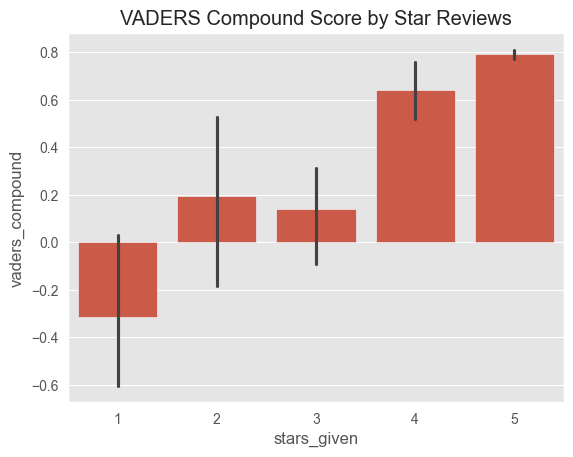

In [18]:
ax = sns.barplot(data=vaders, x="stars_given", y="vaders_compound")
ax.set_title("VADERS Compound Score by Star Reviews")

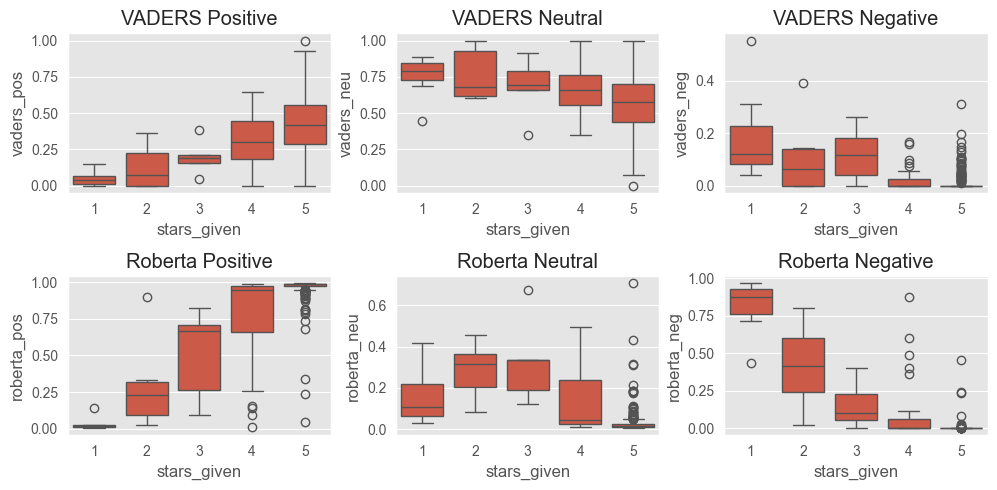

In [19]:
fig, axs = plt.subplots(2, 3, figsize=(10, 5))
sns.boxplot(data=sentiment_df, x="stars_given", y="vaders_pos", ax=axs[0, 0])
sns.boxplot(data=sentiment_df, x="stars_given", y="vaders_neu", ax=axs[0, 1])
sns.boxplot(data=sentiment_df, x="stars_given", y="vaders_neg", ax=axs[0, 2])
axs[0, 0].set_title("VADERS Positive")
axs[0, 1].set_title("VADERS Neutral")
axs[0, 2].set_title("VADERS Negative")
sns.boxplot(data=sentiment_df, x="stars_given", y="roberta_pos", ax=axs[1, 0])
sns.boxplot(data=sentiment_df, x="stars_given", y="roberta_neu", ax=axs[1, 1])
sns.boxplot(data=sentiment_df, x="stars_given", y="roberta_neg", ax=axs[1, 2])
axs[1, 0].set_title("Roberta Positive")
axs[1, 1].set_title("Roberta Neutral")
axs[1, 2].set_title("Roberta Negative")
plt.tight_layout()
plt.show()

<Axes: xlabel='stars_given', ylabel='roberta_compound'>

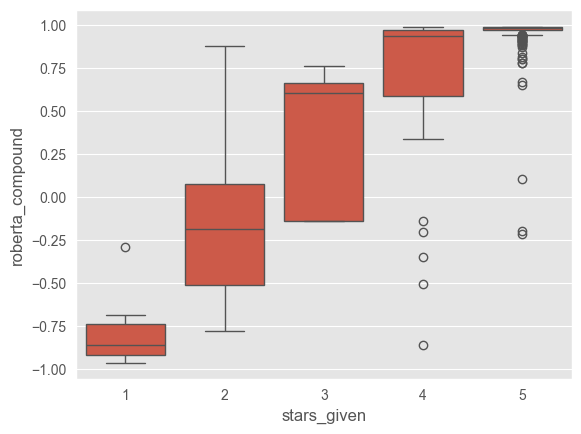

In [20]:
sns.boxplot(
    data=sentiment_df,
    x="stars_given",
    y="roberta_compound"
)

<Axes: xlabel='stars_given', ylabel='vaders_compound'>

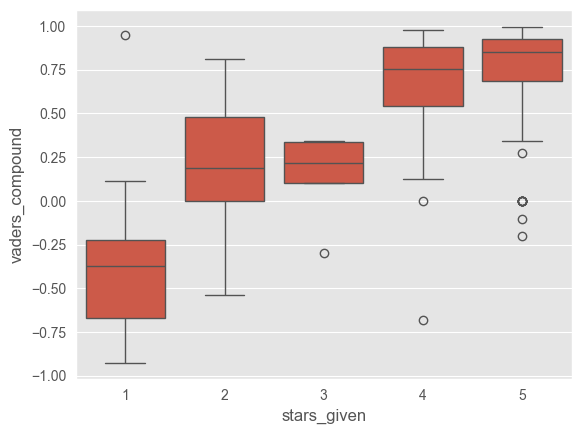

In [21]:
sns.boxplot(
    data=sentiment_df,
    x="stars_given",
    y="vaders_compound"
)

### Sentiment Analysis Results

Both sentiment models demonstrated a relationship between sentiment scores and customer ratings. However, the RoBERTa transformer model appears much more discriminative, creating greater separation between rating categories than VADER. Positive sentiment scores increased consistently from one-star to five-star reviews, while negative sentiment scores decreased. In contrast, VADER classified a large proportion of review text as neutral regardless of rating level, most likely due to the limitations of lexicon-based sentiment analysis approaches. These findings are consistent with the higher F1 score observed for RoBERTa and suggest that contextual transformer-based models capture review sentiment more effectively than lexicon-based approaches.

The most interesting find is the variance in RoBERTa's two-star reviews, which appear very spread in their sentiment intensity. This may suggest that many two-star reviews contain positive language, but the review is dominated by one operational issue.

## Topic Modeling with BERTopic

In [37]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

docs = sentiment_df['full_clean_review'].tolist()

# our vectorizor will remove common english stopwords, capture words in at least two reviews, and capture one and two word phrases
vectorizer = CountVectorizer(
    stop_words='english',
    min_df=2,
    ngram_range=(1, 2),
)

ctfidf = ClassTfidfTransformer(reduce_frequent_words=True)

topic_model = BERTopic(
    vectorizer_model=vectorizer,
    ctfidf_model=ctfidf,
    language='english',
    calculate_probabilities=True,
    verbose=True,
    nr_topics='auto',
    min_topic_size=5
)

topics, probs = topic_model.fit_transform(docs)
sentiment_df['topic'] = topics
sentiment_df['topic_prob'] = probs.max(axis=1)

topic_info = topic_model.get_topic_info()
topic_info

2026-06-09 13:31:34,386 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

2026-06-09 13:31:38,644 - BERTopic - Embedding - Completed ✓
2026-06-09 13:31:38,645 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-09 13:31:39,118 - BERTopic - Dimensionality - Completed ✓
2026-06-09 13:31:39,120 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 13:31:39,174 - BERTopic - Cluster - Completed ✓
2026-06-09 13:31:39,176 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-09 13:31:39,226 - BERTopic - Representation - Completed ✓
2026-06-09 13:31:39,227 - BERTopic - Topic reduction - Reducing number of topics
2026-06-09 13:31:39,235 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 13:31:39,267 - BERTopic - Representation - Completed ✓
2026-06-09 13:31:39,269 - BERTopic - Topic reduction - Reduced number of topics from 20 to 20


,Topic,Count,Name,Representation,Representative_Docs
0,-1,130,-1_really_years_beer_venue,"[really, years, beer, venue, parking, years ag...",[absolutely amazing performance i really didnt...
1,0,46,0_beautiful theater_theater beautiful_beautifu...,"[beautiful theater, theater beautiful, beautif...",[third avenue playhouse is a professional thea...
2,1,29,1_actors_cheeseheads_authentic_magical,"[actors, cheeseheads, authentic, magical, hila...",[super fun experience i didnt love the story l...
3,2,23,2_county_door_door county_trip,"[county, door, door county, trip, county great...",[better than theater in chicago and la if your...
4,3,21,3_funny_wonderful time_family friendly_great s...,"[funny, wonderful time, family friendly, great...",[we have never seen a bad show ever family fri...
5,4,19,4_bad seat_seat house_seat_buy,"[bad seat, seat house, seat, buy, house, peopl...",[great seating due to being a smaller venue it...
6,5,18,5_drinks_friendly staff_friendly_staff,"[drinks, friendly staff, friendly, staff, atmo...",[beautiful building and very friendly staff dr...
7,6,18,6_meyer_meyer theater_helpful_feels,"[meyer, meyer theater, helpful, feels, things,...",[hi just wanted to let you know that we have b...
8,7,17,7_northern sky_northern_peninsula_sky,"[northern sky, northern, peninsula, sky, state...",[outdoor entertainment among the pines this op...
9,8,13,8_frank_let frank_let_franks,"[frank, let frank, let, franks, frank producti...",[really enjoyed the let me be frank show fun v...


#### Topic Overview and Topic-Sentiment Analysis

Topic -1 is BERTopic's "outlier" bucket - reviews that didn't fit any topic cleanly.

0: Theater Atmosphere <br>
1: Acting & Performance <br>
2: Door County Tourism <br>
3: General Enjoyment <br>
4: Seating Complaints <br>
5: Staff & Drinks <br>
6: Meyer Theater <br>
7: Northern Peninsula Tourism <br>
8: Frank Productions <br>
9: Seating & Acoustics <br>
10: Grounds & Outdoor <br>
11: Venue & Facilities <br>
12: Bucket List Experience <br>
13: Concert Experience <br>
14: Christmas/ABBA Show <br>
15: Performer Talent <br>
16: Family Entertainment <br>
17: Evening Entertainment <br>
18: Daredevils Show

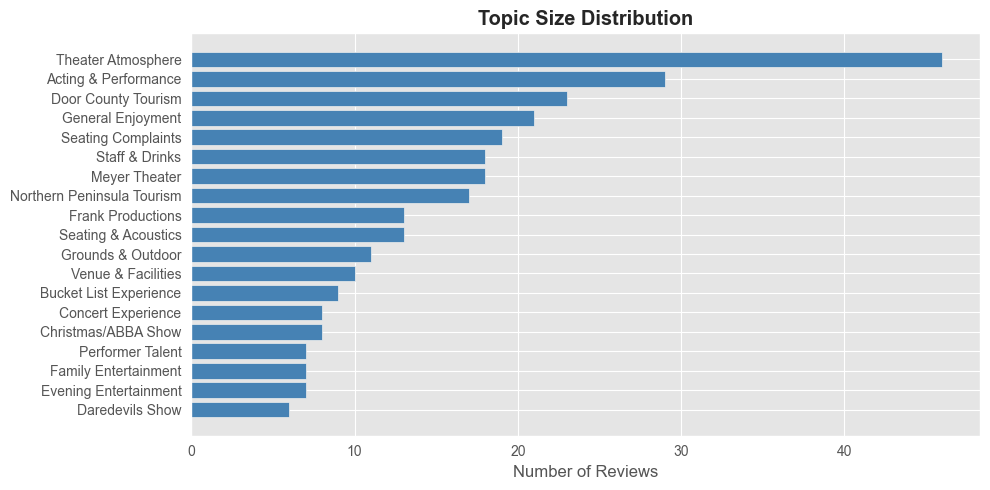

In [51]:
topic_label_map = {
    13: "Concert Experience",
    17: "Evening Entertainment",
    7:  "Northern Peninsula Tourism",
    16: "Family Entertainment",
    11: "Venue & Facilities",
    3:  "General Enjoyment",
    6:  "Meyer Theater",
    1:  "Acting & Performance",
    8:  "Frank Productions",
    12: "Bucket List Experience",
    15: "Performer Talent",
    9:  "Seating & Acoustics",
    18: "Daredevils Show",
    2:  "Door County Tourism",
    0:  "Theater Atmosphere",
    5:  "Staff & Drinks",
    10: "Grounds & Outdoor",
    4:  "Seating Complaints",
    14: "Christmas/ABBA Show",
    -1: "Outlier"
}

topic_info['Name'] = topic_info['Topic'].map(topic_label_map)
sentiment_df['topic_name'] = sentiment_df['topic'].map(topic_label_map)

topic_sizes = topic_info[topic_info['Topic'] != -1].copy()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    topic_sizes['Name'].astype(str),
    topic_sizes['Count'],
    color='steelblue'
)
ax.set_xlabel('Number of Reviews')
ax.set_title('Topic Size Distribution', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [52]:
topic_sentiment = (
    sentiment_df[sentiment_df['topic'] != -1]
    .groupby('topic')
    .agg(
        review_count=('topic', 'count'),
        avg_stars=('stars_given', 'mean'),
        avg_roberta_compound=('roberta_compound', 'mean'),
        pct_negative=('true_label', lambda a: (a == 'negative').mean() * 100)
    )
    .reset_index()
)

topic_names = topic_info[topic_info['Topic'] != -1][['Topic', 'Name']].rename(columns={'Topic' : 'topic'})
topic_sentiment = topic_sentiment.merge(topic_names, on='topic')

topic_sentiment = topic_sentiment.sort_values('avg_stars', ascending=False)
topic_sentiment

,topic,review_count,avg_stars,avg_roberta_compound,pct_negative,Name
13,13,8,5.000000,0.980133,0.000000,Concert Experience
17,17,7,5.000000,0.972368,0.000000,Evening Entertainment
7,7,17,5.000000,0.975157,0.000000,Northern Peninsula Tourism
16,16,7,5.000000,0.928499,0.000000,Family Entertainment
11,11,10,5.000000,0.963459,0.000000,Venue & Facilities
3,3,21,4.952381,0.887654,0.000000,General Enjoyment
6,6,18,4.944444,0.902704,0.000000,Meyer Theater
1,1,29,4.931034,0.967648,0.000000,Acting & Performance
8,8,13,4.923077,0.967247,0.000000,Frank Productions
12,12,9,4.888889,0.981369,0.000000,Bucket List Experience


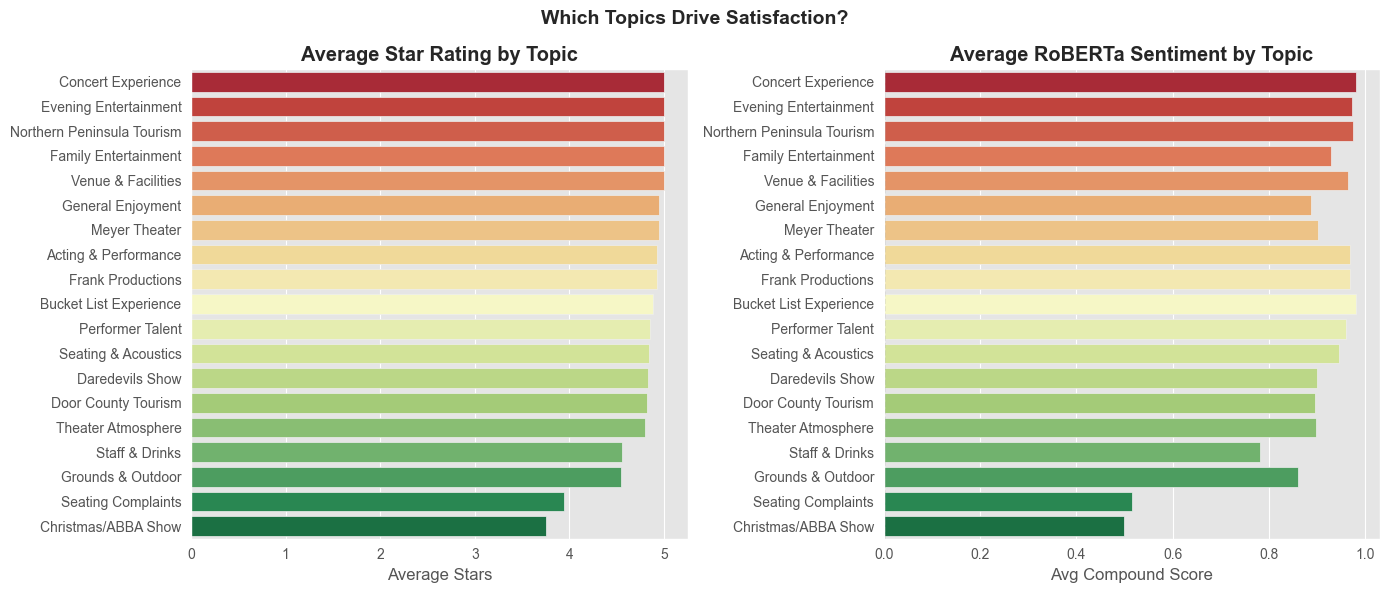

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# average stars by topic
sns.barplot(
    data=topic_sentiment,
    x='avg_stars',
    y='Name',
    palette='RdYlGn',
    ax=axes[0]
)
axes[0].set_title('Average Star Rating by Topic', fontweight='bold')
axes[0].set_xlabel('Average Stars')
axes[0].set_ylabel('')


# average RoBERTa compound score by topic
sns.barplot(
    data=topic_sentiment,
    x='avg_roberta_compound',
    y='Name',
    palette='RdYlGn',
    ax=axes[1]
)
axes[1].set_title('Average RoBERTa Sentiment by Topic', fontweight='bold')
axes[1].set_xlabel('Avg Compound Score')
axes[1].set_ylabel('')
axes[1].axvline(x=0, color='gray', linestyle='--', linewidth=1)

plt.suptitle('Which Topics Drive Satisfaction?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

topic_category
General            98
Performance        72
Operational        71
Tourism Context    49
Name: count, dtype: int64


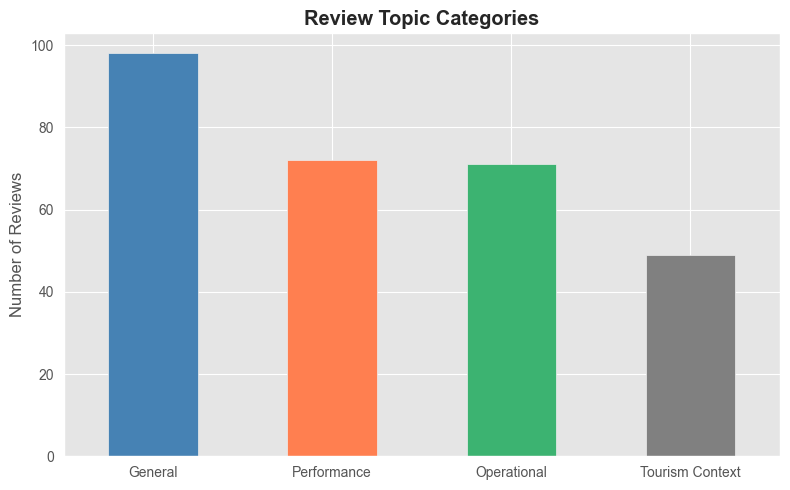

,topic_category,avg_stars,avg_sentiment,count
0,General,4.877551,0.905810,98
1,Operational,4.507042,0.778597,71
2,Performance,4.805556,0.907169,72
3,Tourism Context,4.897959,0.938457,49


In [55]:
performance_topics = [13, 17, 16, 1, 15, 18, 14]
tourism_topics     = [2, 7, 12]
operational_topics = [9, 4, 5, 10, 11]

def categorize_topic(t):
    if t in performance_topics:
        return 'Performance'
    elif t in tourism_topics:
        return 'Tourism Context'
    elif t in operational_topics:
        return 'Operational'
    else:
        return 'General'

sentiment_df['topic_category'] = sentiment_df['topic'].apply(categorize_topic)

cat_counts = sentiment_df[sentiment_df['topic'] != -1]['topic_category'].value_counts()
print(cat_counts)

fig, ax = plt.subplots(figsize=(8, 5))
cat_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'mediumseagreen', 'gray'])
ax.set_title('Review Topic Categories', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

cat_sentiment = (
    sentiment_df[sentiment_df['topic'] != -1]
    .groupby('topic_category')
    .agg(
        avg_stars=('stars_given', 'mean'),
        avg_sentiment=('roberta_compound', 'mean'),
        count=('topic', 'count')
    )
    .reset_index()
)
cat_sentiment

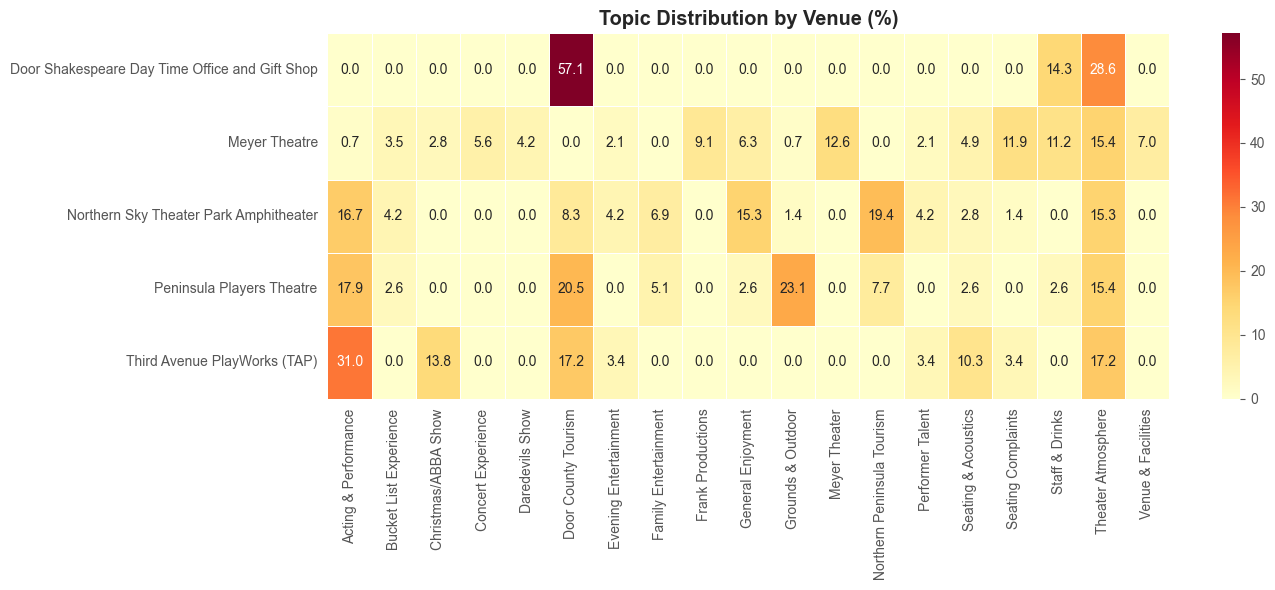

In [56]:
# venue topic distribution
# Answers: do different theaters attract reviews about different topics?

venue_topic = (
    sentiment_df[sentiment_df['topic'] != -1]
    .groupby(['venue_name', 'topic'])
    .size()
    .reset_index(name='count')
)

venue_topic['pct'] = venue_topic.groupby('venue_name')['count'].transform(
    lambda b: b / b.sum() * 100
)

venue_topic = venue_topic.merge(topic_names, on='topic')

pivot = venue_topic.pivot(index='venue_name', columns='Name', values='pct').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5
)
ax.set_title('Topic Distribution by Venue (%)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### Topic Modeling Results


In [58]:
def show_topic_examples(topic_num, n=3):
    samples = (
        sentiment_df[sentiment_df['topic'] == topic_num]['review_text']
        .sample(min(n, len(sentiment_df[sentiment_df['topic'] == topic_num])),
                random_state=42)
        .tolist()
    )
    topic_name = topic_info[topic_info['Topic'] == topic_num]['Name'].values[0]
    print(f"\n── Topic {topic_num}: {topic_name} ──")
    for i, r in enumerate(samples, 1):
        print(f"{i}. {r}\n")

# Print examples for each non-outlier topic
for t in [4, 5, 10]:
    show_topic_examples(t)


── Topic 4: Seating Complaints ──
1. Arrived at 7 pm for 7:30 pm performance via uber. Were told box office closed at 7. Get tickets on line. Tried that, but it also stopped at 7.  Tried to see if we could buy a ticket for tomorrow, but watch tonight. People at the theater would not allow.  Now waitng for another uber. Spent $30 in ubers and saw no play. Wont be back

2. Trying to buy tickets is very deceiving,

3. We rented the theater for our wedding ceremony and the backstage for our reception. They let us set up early, which I did not expect at all and it made things very easy. Samantha listened to our ideas and made them all possible. The space is beautiful and historic and we were so fortunate to be able to have our wedding there. It was very easy to work with their AV technician for sound during the ceremony. Backstage was perfect and was able to transform from a seated dinner to an amazing dance floor. The accommodations were amazing. The only thing I would retract from was a 